# Vertical velocity: low- vs high-resolution TPOSE

How different is the vertical velocity **W** between the low-resolution
**TPOSE6 (1/6°)** assimilation and the three high-resolution **TPOSE24 (1/24°)**
nested runs (Ri3, Ri5, Ri7), over Oct–Dec 2012?

Contents:
1. Animations of W on the ~100 m level — TPOSE6 vs each TPOSE24 run.
2. Distributions of W at 0°N, 140°W — vs depth and vs time.
3. Mean W profiles with 95% confidence intervals (from the standard error).

W is the flux across the top face of each cell (on the `Zl` coordinate,
positive up). The first 10 days of each run are dropped as initialization shock.
The high-resolution runs output 3-hourly and the low-resolution run daily; for
the point distributions and mean profiles every series is reduced to daily means
so the comparison is at a common cadence.

In [1]:
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cmocean.cm as cmo
import wvel_utils as wu
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

ORDER  = wu.MODEL_ORDER                       # TP6, Ri3, Ri5, Ri7
COLORS = {'TP6': 'k', 'Ri3': 'tab:blue', 'Ri5': 'tab:green', 'Ri7': 'tab:orange'}

C = {m: xr.open_dataset(wu.cache_path(f'wvel_cache_{m}.nc')) for m in ORDER}
LABEL = {m: C[m].attrs['label'] for m in ORDER}
for m in ORDER:
    print(f"{m:4s} {LABEL[m]:22s} col={dict(C[m].w_col.sizes)}  "
          f"anim frames={C[m].sizes['time_anim']}  Zl_anim={C[m].attrs['anim_depth_m']:.1f} m")


TP6  TPOSE6 (1/6°)          col={'time': 122, 'depth': 66}  anim frames=122  Zl_anim=-100.0 m
Ri3  TPOSE24 Ri3 (1/24°)    col={'time': 727, 'depth': 138}  anim frames=182  Zl_anim=-100.0 m
Ri5  TPOSE24 Ri5 (1/24°)    col={'time': 727, 'depth': 138}  anim frames=182  Zl_anim=-100.0 m
Ri7  TPOSE24 Ri7 (1/24°)    col={'time': 727, 'depth': 138}  anim frames=182  Zl_anim=-100.0 m


In [2]:
# daily-mean W(time, depth) at 0N,140W, in mm/s
WCOL_ALL = {m: (C[m].w_col * 1e3).resample(time='1D').mean() for m in ORDER}

# Common comparison window: after every run's 10-day spin-up, over the overlap.
t_lo = max(pd.Timestamp(WCOL_ALL[m].time.values[0]) + pd.Timedelta(days=wu.SPINUP_DAYS)
           for m in ORDER)
t_hi = min(pd.Timestamp(WCOL_ALL[m].time.values[-1]) for m in ORDER)
print(f'common window: {t_lo.date()} .. {t_hi.date()}')

WCOL = {m: WCOL_ALL[m].sel(time=slice(t_lo, t_hi)) for m in ORDER}
for m in ORDER:
    print(f"{m}: {WCOL[m].sizes['time']} daily columns, "
          f"depth {float(WCOL[m].depth.min()):.0f}..{float(WCOL[m].depth.max()):.0f} m")

DEPTH = {m: WCOL[m].depth.values for m in ORDER}


common window: 2012-10-11 .. 2012-12-30
TP6: 81 daily columns, depth -5500..0 m
Ri3: 81 daily columns, depth -5400..0 m
Ri5: 81 daily columns, depth -5400..0 m
Ri7: 81 daily columns, depth -5400..0 m


## 1. Animations of W on the ~100 m level

Side-by-side low- vs high-resolution. The low-resolution field is shown over the
TPOSE24 footprint plus a 5° surrounding buffer; the high-resolution panels cover
the TPOSE24 domain. A common symmetric colour scale (robust 99th percentile) is
used so magnitudes are directly comparable.

In [3]:
# Common colour scale across all runs, robust to outliers.
vmax = max(float(np.nanpercentile(np.abs(C[m].w_slice.values), 99)) for m in ORDER) * 1e3
vmax = round(vmax, 2)
print(f'W animation colour limit: +/- {vmax:.2f} mm/s at ~100 m')

# Common daily frame axis over the post-spin-up overlap; each panel picks nearest time.
frame_times = pd.date_range(t_lo.ceil('D'), t_hi.floor('D'), freq='1D')
print(f'{len(frame_times)} frames, {frame_times[0].date()} .. {frame_times[-1].date()}')


W animation colour limit: +/- 0.36 mm/s at ~100 m
81 frames, 2012-10-11 .. 2012-12-30


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
axes = axes.ravel()
meshes = []
for ax, m in zip(axes, ORDER):
    s0 = C[m].w_slice.sel(time_anim=frame_times[0], method='nearest') * 1e3
    pm = ax.pcolormesh(C[m].XC, C[m].YC, s0, cmap=cmo.balance,
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.plot(wu.TARGET_LON, wu.TARGET_LAT, 'k+', ms=10, mew=1.5)
    ax.set_title(LABEL[m]); ax.set_xlabel('lon (°E)'); ax.set_ylabel('lat (°N)')
    meshes.append(pm)
cb = fig.colorbar(meshes[-1], ax=axes, shrink=0.7)
cb.set_label('W at ~100 m (mm/s)')
sup = fig.suptitle(str(frame_times[0].date()), fontsize=14)

def update(k):
    for pm, m in zip(meshes, ORDER):
        s = C[m].w_slice.sel(time_anim=frame_times[k], method='nearest') * 1e3
        pm.set_array(np.asarray(s.values).ravel())
    sup.set_text(str(frame_times[k].date()))
    return meshes + [sup]

anim = animation.FuncAnimation(fig, update, frames=len(frame_times), blit=False)
anim.save('W_100m_lowres_vs_highres.gif', writer=animation.PillowWriter(fps=8))
plt.close(fig)
print('saved W_100m_lowres_vs_highres.gif')


saved W_100m_lowres_vs_highres.gif


In [5]:
# Also a direct low-res vs high-res(Ri5) pair at higher magnification of the equatorial band.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), constrained_layout=True)
pair = ['TP6', 'Ri5']
meshes = []
for ax, m in zip(axes, pair):
    s0 = C[m].w_slice.sel(time_anim=frame_times[0], method='nearest') * 1e3
    pm = ax.pcolormesh(C[m].XC, C[m].YC, s0, cmap=cmo.balance,
                       vmin=-vmax, vmax=vmax, shading='auto')
    ax.set_ylim(-6, 6); ax.axhline(0, color='0.4', lw=0.6)
    ax.plot(wu.TARGET_LON, wu.TARGET_LAT, 'k+', ms=10, mew=1.5)
    ax.set_title(LABEL[m]); ax.set_xlabel('lon (°E)'); ax.set_ylabel('lat (°N)')
    meshes.append(pm)
cb = fig.colorbar(meshes[-1], ax=axes, shrink=0.85); cb.set_label('W at ~100 m (mm/s)')
sup = fig.suptitle(str(frame_times[0].date()), fontsize=13)

def update2(k):
    for pm, m in zip(meshes, pair):
        s = C[m].w_slice.sel(time_anim=frame_times[k], method='nearest') * 1e3
        pm.set_array(np.asarray(s.values).ravel())
    sup.set_text(str(frame_times[k].date()))
    return meshes + [sup]

anim2 = animation.FuncAnimation(fig, update2, frames=len(frame_times), blit=False)
anim2.save('W_100m_TP6_vs_Ri5_equator.gif', writer=animation.PillowWriter(fps=8))
plt.close(fig)
print('saved W_100m_TP6_vs_Ri5_equator.gif')


saved W_100m_TP6_vs_Ri5_equator.gif


## 2. Distributions of W at 0°N, 140°W

### 2a. Distribution vs depth
Percentile envelope of daily W over the whole record at each depth (median with
25–75% and 5–95% bands), overlaid across models, plus the standard deviation of
W with depth. This shows how much more vertical-velocity variance the 1/24° runs
carry relative to 1/6°.

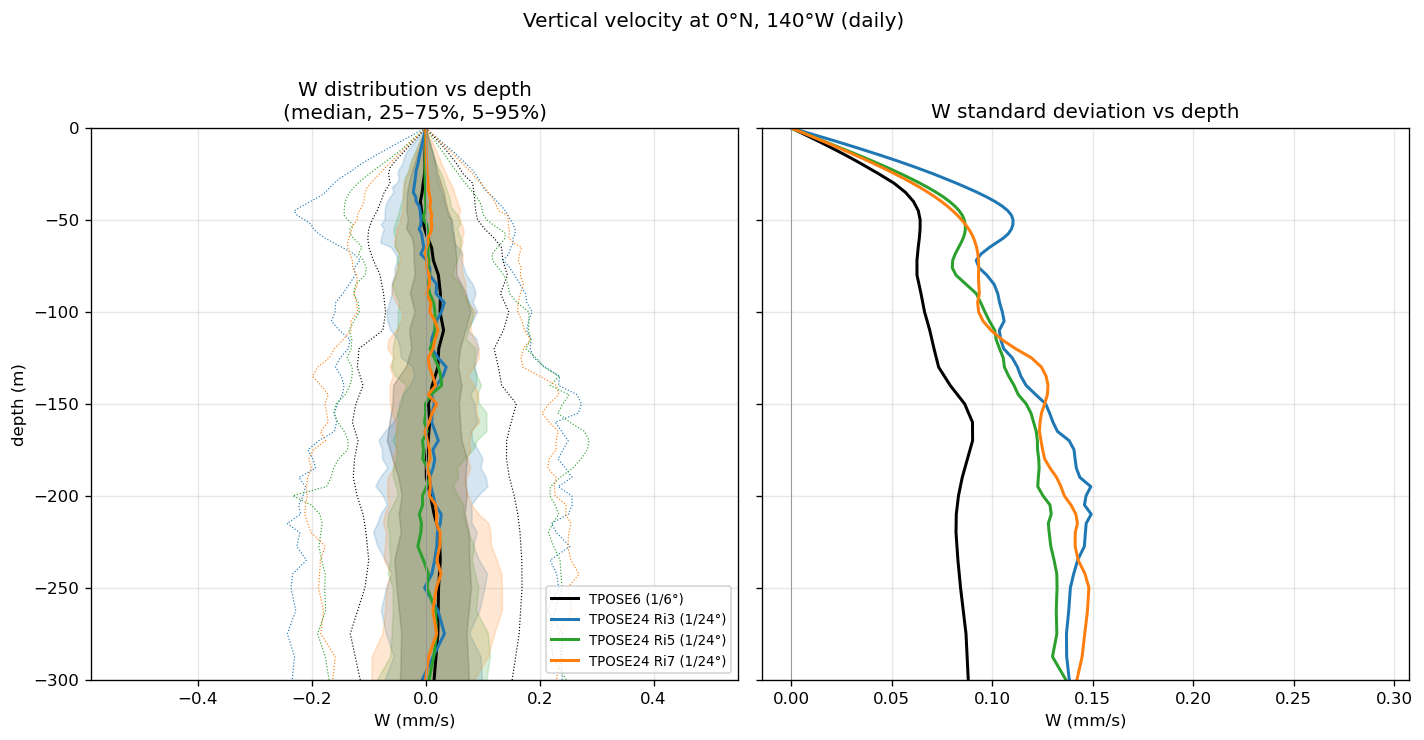

In [6]:
fig, (axp, axs) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
for m in ORDER:
    w = WCOL[m].values                     # (time, depth) mm/s
    z = DEPTH[m]
    p05, p25, p50, p75, p95 = np.nanpercentile(w, [5, 25, 50, 75, 95], axis=0)
    c = COLORS[m]
    axp.plot(p50, z, color=c, lw=1.8, label=LABEL[m])
    axp.fill_betweenx(z, p25, p75, color=c, alpha=0.18)
    axp.plot(p05, z, color=c, lw=0.7, ls=':'); axp.plot(p95, z, color=c, lw=0.7, ls=':')
    axs.plot(np.nanstd(w, axis=0), z, color=c, lw=1.8, label=LABEL[m])
for ax in (axp, axs):
    ax.set_ylim(-300, 0); ax.axvline(0, color='0.6', lw=0.6); ax.grid(alpha=0.3)
    ax.set_xlabel('W (mm/s)');
axp.set_ylabel('depth (m)')
axp.set_title('W distribution vs depth\n(median, 25–75%, 5–95%)')
axs.set_title('W standard deviation vs depth')
axp.legend(fontsize=8, loc='lower right')
fig.suptitle('Vertical velocity at 0°N, 140°W (daily)', y=1.02)
fig.tight_layout(); fig.savefig('W_dist_vs_depth_0N140W.png', dpi=140, bbox_inches='tight')
plt.show()


### 2b. Distribution vs time
Hovmöller of daily W(depth, time) at 0°N, 140°W for each model (same colour
scale), and the distribution of W over time within the upwelling core (0–200 m)
as monthly box-and-whiskers.

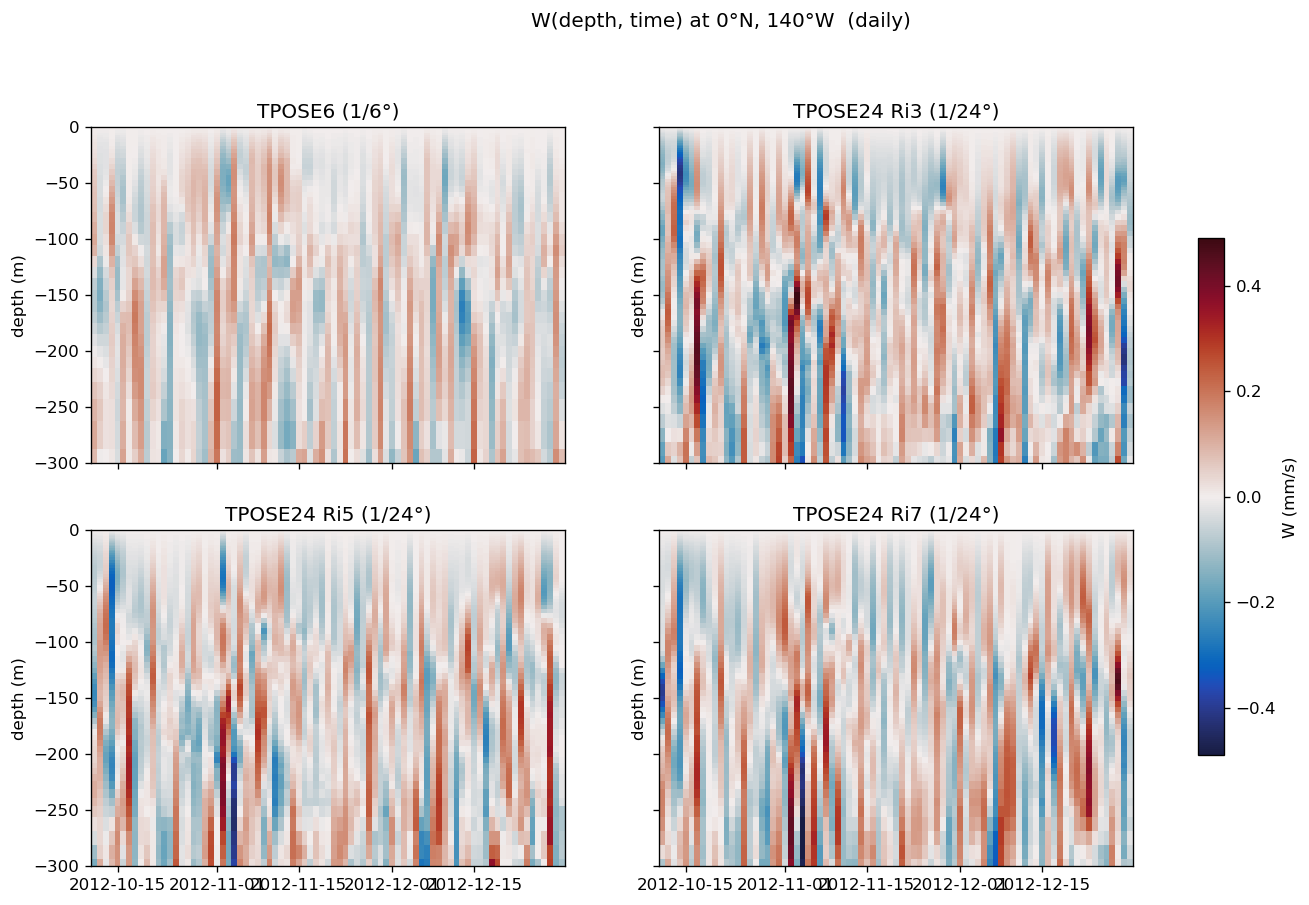

In [7]:
vh = max(float(np.nanpercentile(np.abs(WCOL[m].values), 99)) for m in ORDER)
vh = round(vh, 2)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, m in zip(axes.ravel(), ORDER):
    w = WCOL[m]
    pm = ax.pcolormesh(w.time.values, DEPTH[m], w.values.T, cmap=cmo.balance,
                       vmin=-vh, vmax=vh, shading='auto')
    ax.set_ylim(-300, 0); ax.set_title(LABEL[m]); ax.set_ylabel('depth (m)')
cb = fig.colorbar(pm, ax=axes, shrink=0.7); cb.set_label('W (mm/s)')
fig.suptitle('W(depth, time) at 0°N, 140°W  (daily)', y=1.0)
fig.savefig('W_hovmoller_0N140W.png', dpi=140, bbox_inches='tight')
plt.show()


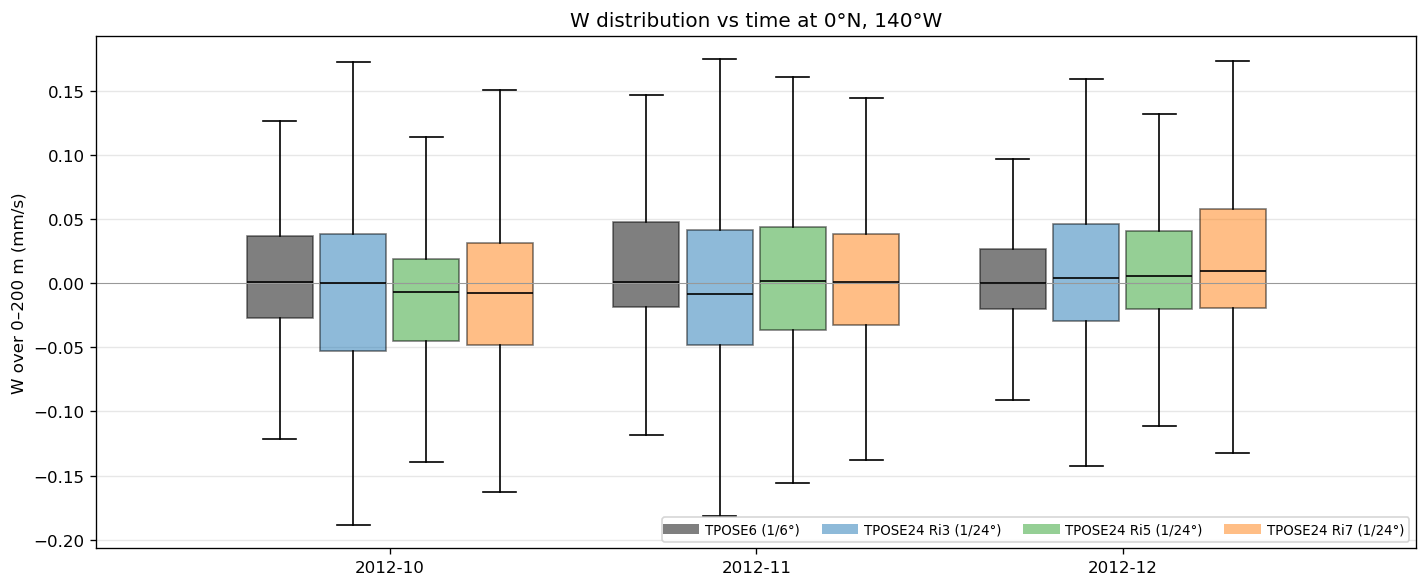

In [8]:
# W distribution over time in the 0-200 m core: monthly box-and-whiskers per model.
fig, ax = plt.subplots(figsize=(12, 5))
months = ['2012-10', '2012-11', '2012-12']
width = 0.8 / len(ORDER)
for mi, m in enumerate(ORDER):
    w = WCOL[m].sel(depth=slice(0, -200))
    data = []
    for mon in months:
        sub = w.sel(time=mon).values.ravel()
        data.append(sub[np.isfinite(sub)])
    pos = np.arange(len(months)) + (mi - (len(ORDER)-1)/2) * width
    bp = ax.boxplot(data, positions=pos, widths=width*0.9, patch_artist=True,
                    showfliers=False, medianprops=dict(color='k'))
    for box in bp['boxes']:
        box.set(facecolor=COLORS[m], alpha=0.5)
    ax.plot([], [], color=COLORS[m], lw=6, alpha=0.5, label=LABEL[m])
ax.set_xticks(range(len(months))); ax.set_xticklabels(months)
ax.axhline(0, color='0.6', lw=0.6); ax.grid(alpha=0.3, axis='y')
ax.set_ylabel('W over 0–200 m (mm/s)'); ax.set_title('W distribution vs time at 0°N, 140°W')
ax.legend(fontsize=8, ncol=len(ORDER))
fig.tight_layout(); fig.savefig('W_dist_vs_time_0N140W.png', dpi=140, bbox_inches='tight')
plt.show()


## 3. Mean W profiles with 95% confidence intervals

Time-mean W(z) at 0°N, 140°W for each model with the 95% CI half-width from the
standard error (CI = 1.96·σ/√N over the daily samples). The right panel is the
same but zoomed to the near-surface where equatorial upwelling peaks.

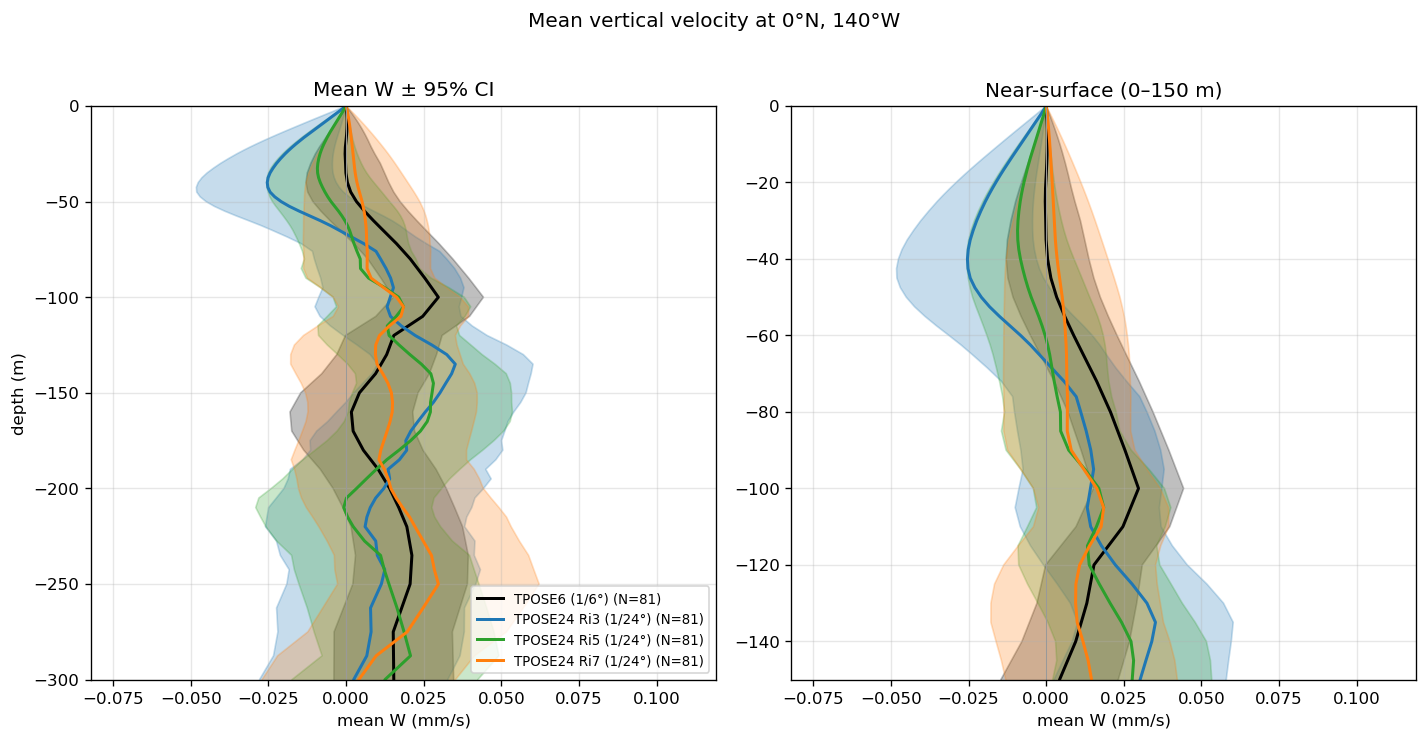

In [9]:
fig, (axf, axz) = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
for m in ORDER:
    w = WCOL[m].values
    z = DEPTH[m]
    mean, half, std, n = wu.mean_ci(w, axis=0)
    c = COLORS[m]
    for ax in (axf, axz):
        ax.plot(mean, z, color=c, lw=1.8, label=f'{LABEL[m]} (N={int(np.nanmax(n))})')
        ax.fill_betweenx(z, mean - half, mean + half, color=c, alpha=0.25)
for ax in (axf, axz):
    ax.axvline(0, color='0.6', lw=0.6); ax.grid(alpha=0.3); ax.set_xlabel('mean W (mm/s)')
axf.set_ylabel('depth (m)'); axf.set_ylim(-300, 0); axf.set_title('Mean W ± 95% CI')
axz.set_ylim(-150, 0); axz.set_title('Near-surface (0–150 m)')
axf.legend(fontsize=8, loc='lower right')
fig.suptitle('Mean vertical velocity at 0°N, 140°W', y=1.02)
fig.tight_layout(); fig.savefig('W_mean_profile_CI_0N140W.png', dpi=140, bbox_inches='tight')
plt.show()


In [10]:
# Summary table: peak upwelling and near-surface variability per model.
rows = []
for m in ORDER:
    w = WCOL[m]
    core = w.sel(depth=slice(0, -200))
    mean, half, std, n = wu.mean_ci(w.values, axis=0)
    upper = DEPTH[m] >= -250                  # restrict peak search to upper ocean
    mup = np.where(upper, mean, np.nan)
    kpk = int(np.nanargmax(mup))              # strongest mean upwelling level
    rows.append(dict(model=LABEL[m],
                     peak_mean_W=round(float(mean[kpk]), 3),
                     peak_depth_m=round(float(DEPTH[m][kpk]), 0),
                     std_0_200m=round(float(np.nanstd(core.values)), 3),
                     N_days=int(np.nanmax(n))))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv('W_summary_0N140W.csv', index=False)


              model  peak_mean_W  peak_depth_m  std_0_200m  N_days
      TPOSE6 (1/6°)        0.030        -100.0       0.061      81
TPOSE24 Ri3 (1/24°)        0.035        -135.0       0.097      81
TPOSE24 Ri5 (1/24°)        0.028        -145.0       0.083      81
TPOSE24 Ri7 (1/24°)        0.030        -250.0       0.087      81
